# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
(28221, 10)
<class 'pandas.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          28221 non-null  int64
 1   OPEID                       28221 non-null  int64
 2   Institution Name            28221 non-null  str  
 3   City                        28221 non-null  str  
 4   State                       28221 non-null  str  
 5   Foreign Gift Received Date  28221 non-null  int64
 6   Foreign Gift Amount         28221 non-null  int64
 7   Gift Type                   28221 non-null  str  
 8   Country of Giftor           28221 non-null  str  
 9   Giftor Name                 24470 non-null  str  
dtypes: int64(4), str(6)
memory usage: 2.2 MB
ID     

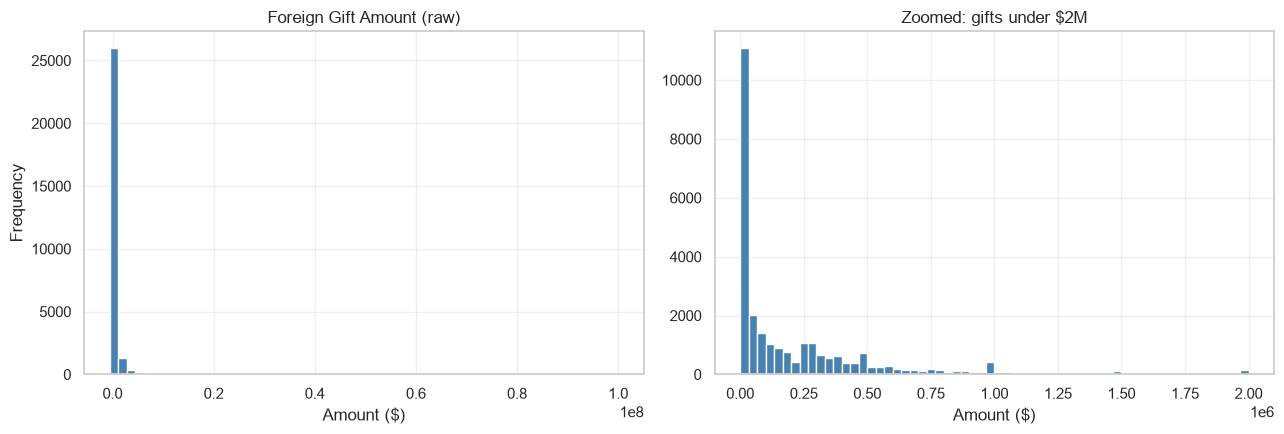

Non-positive records: 24


,count,proportion (%)
Gift Type,,
Contract,17274,61.21
Monetary Gift,10936,38.75
Real Estate,11,0.04


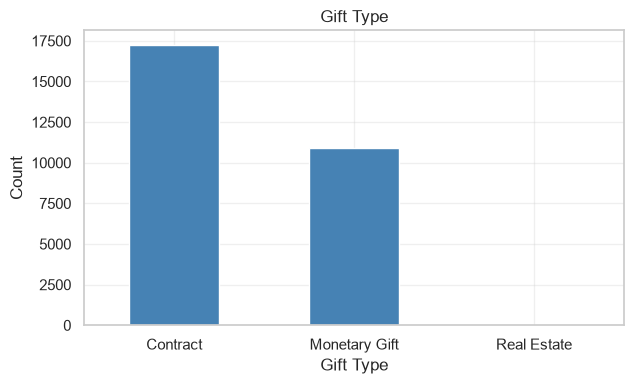

Dropped 24 non-positive records before logging


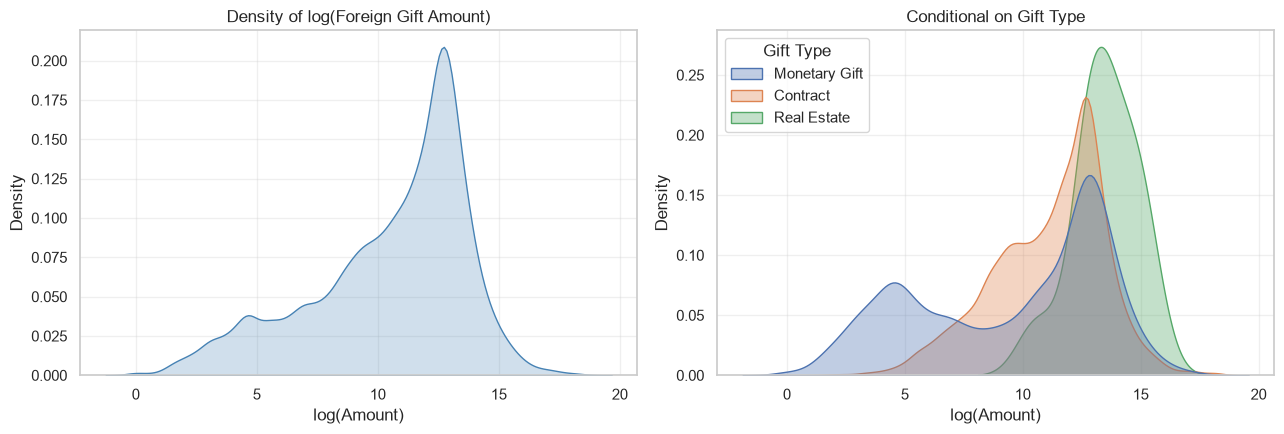

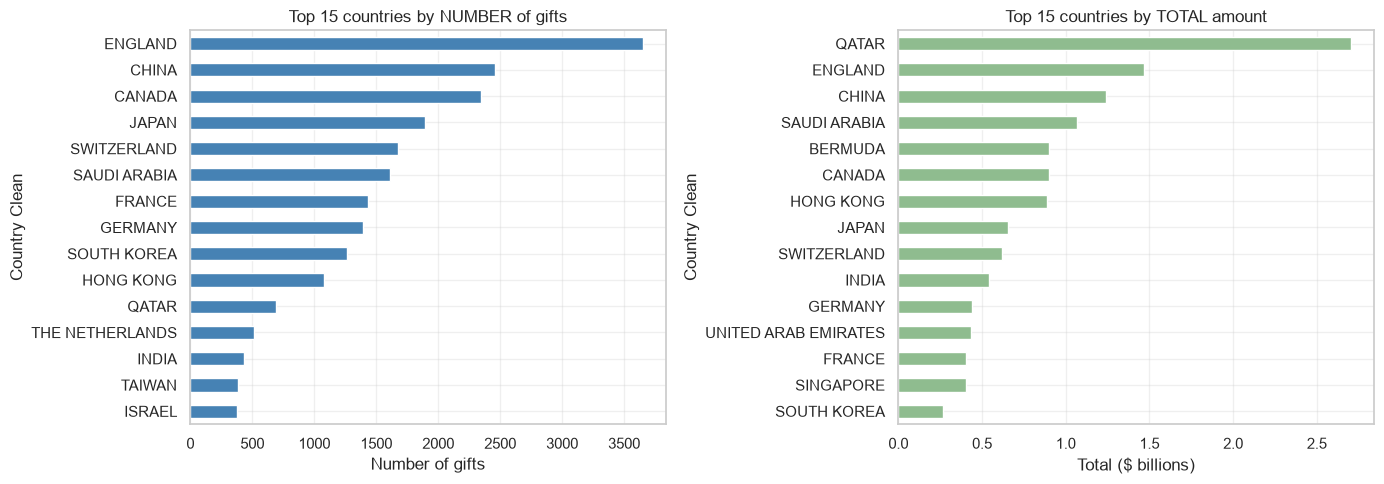

,total,n_gifts,avg_gift
Giftor Name,,,
Qatar Foundation,1166503744,261,"4,469,363.00"
Qatar Foundation/Qatar National Res,796197000,10,"79,619,700.00"
Qatar Foundation for Education,373945215,6,"62,324,202.50"
Anonymous,338793629,262,"1,293,105.45"
Saudi Arabian Cultural Mission,275221475,480,"573,378.07"
HCL,190000000,5,"38,000,000.00"
Church of Jesus Christ of LDS,185203715,7,"26,457,673.57"
Emirates Institute for Advanced Sc,170641244,24,"7,110,051.83"
QIC,148355497,2,"74,177,748.50"


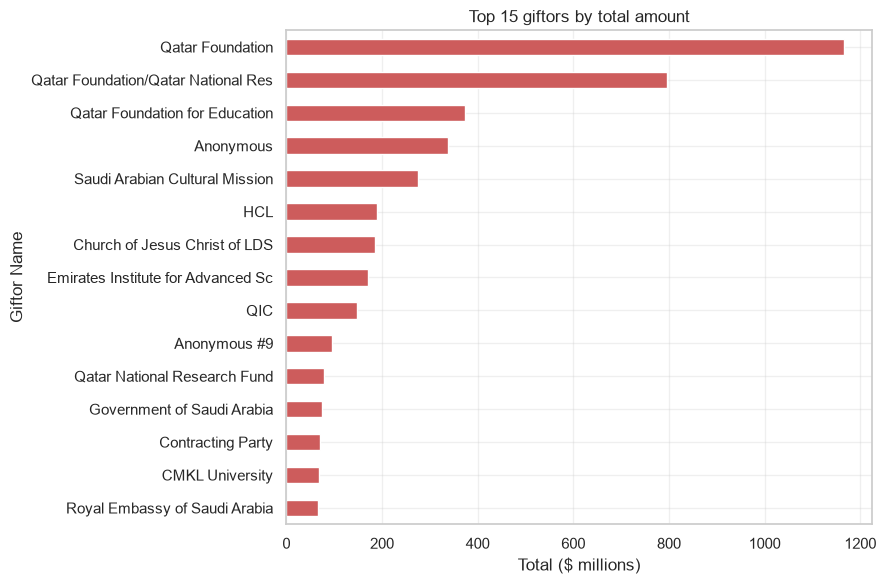

All Qatar-named giftors: $2.49B across 609 records
Grand total:             $16.60B
Qatar share:             15.0%


Giftor Name
Qatar Foundation                       261
Qatar National Research Fund           124
Qatar National Research Foundation      89
Qatar University                        17
Qatar Research Foundation               17
Qatar Petroleum                         10
Embassy of the State of Qatar           10
Qatar Foundation/Qatar National Res     10
Qatar Foundation for Education           6
Qatar National Research                  6
Name: count, dtype: int64

In [ ]:
# Your Phase 1 solution to the problem goes here.
#Question 1: I have written this in Latex using overleaf. I will upload the pdf to my folder and push it.
#Question 2:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('./data/ForeignGifts_edu.csv')
print(df.shape)
df.head()

df.info()
print(df.isna().sum())
df['Foreign Gift Amount'].describe()

#2.2
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['Foreign Gift Amount'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Foreign Gift Amount (raw)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

sub = df[df['Foreign Gift Amount'].between(0, 2_000_000)]
axes[1].hist(sub['Foreign Gift Amount'], bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Zoomed: gifts under $2M')
axes[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.show()

print("Non-positive records:", (df['Foreign Gift Amount'] <= 0).sum())

#2.3
counts = df['Gift Type'].value_counts()
props  = df['Gift Type'].value_counts(normalize=True)

display(pd.DataFrame({'count': counts, 'proportion (%)': (props * 100).round(2)}))

ax = counts.plot(kind='bar', color='steelblue', figsize=(6.5, 4), rot=0)
ax.set_title('Gift Type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
#2.4
pos = df[df['Foreign Gift Amount'] > 0].copy()
pos['log_amount'] = np.log(pos['Foreign Gift Amount'])
print(f"Dropped {len(df) - len(pos)} non-positive records before logging")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(data=pos, x='log_amount', fill=True, ax=axes[0], color='steelblue')
axes[0].set_title('Density of log(Foreign Gift Amount)')
axes[0].set_xlabel('log(Amount)')

sns.kdeplot(data=pos, x='log_amount', hue='Gift Type',
            fill=True, alpha=0.35, common_norm=False, ax=axes[1])
axes[1].set_title('Conditional on Gift Type')
axes[1].set_xlabel('log(Amount)')

plt.tight_layout()
plt.show()

pos.groupby('Gift Type')['log_amount'].describe().round(2)
#2.5
# KOREA and SOUTH KOREA are separate labels in the raw data; collapse them
df['Country Clean'] = df['Country of Giftor'].replace({'KOREA': 'SOUTH KOREA'})

by_count = (df.groupby('Country Clean')['Foreign Gift Amount']
              .count().sort_values(ascending=False).head(15))

by_sum   = (df.groupby('Country Clean')['Foreign Gift Amount']
              .sum().sort_values(ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_count.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 countries by NUMBER of gifts')
axes[0].set_xlabel('Number of gifts')

(by_sum.sort_values() / 1e9).plot(kind='barh', ax=axes[1], color='darkseagreen')
axes[1].set_title('Top 15 countries by TOTAL amount')
axes[1].set_xlabel('Total ($ billions)')

plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    'rank_by_count': by_count.rank(ascending=False).astype(int),
    'n_gifts': by_count,
}).join(pd.DataFrame({
    'rank_by_amount': by_sum.rank(ascending=False).astype(int),
    'total_$B': (by_sum / 1e9).round(2),
}), how='outer')

comp.sort_values('rank_by_amount')

#2.6
by_giftor = (df.groupby('Giftor Name')['Foreign Gift Amount']
               .agg(total='sum', n_gifts='count')
               .sort_values('total', ascending=False)
               .head(15))
by_giftor['avg_gift'] = by_giftor['total'] / by_giftor['n_gifts']

display(by_giftor)

(by_giftor['total'].sort_values() / 1e6).plot(kind='barh', figsize=(9, 6), color='indianred')
plt.title('Top 15 giftors by total amount')
plt.xlabel('Total ($ millions)')
plt.tight_layout()
plt.show()

qatar = df['Giftor Name'].fillna('').str.contains('Qatar', case=False)
total = df['Foreign Gift Amount'].sum()

print(f"All Qatar-named giftors: ${df.loc[qatar, 'Foreign Gift Amount'].sum()/1e9:.2f}B "
      f"across {qatar.sum()} records")
print(f"Grand total:             ${total/1e9:.2f}B")
print(f"Qatar share:             {df.loc[qatar,'Foreign Gift Amount'].sum()/total*100:.1f}%")

# The variant spellings driving the fragmentation
df.loc[qatar, 'Giftor Name'].value_counts().head(10)




In [ ]:
#Q2.2: Foreign Gift Amount is severely right-skewed, with a mean of $588,233 against a median of $94,615, a minimum of -$537,770 across 24 non-positive records, and a maximum of $99,999,999 that looks like a reporting cap.

#Q2.3: Contracts make up 61.21% of gifts (17,274), monetary gifts 38.75% (10,936), and real estate 0.04% (11), meaning most of this money is commercial rather than philanthropic.

#Q2.4: Monetary gifts are clearly bimodal with a second mode near log 4.5 (about $90) and are far more dispersed than contracts (sd 4.02 vs 2.39), because contracts have a practical floor on size that donations do not.

#Q2.5: England leads by number of gifts (3,655) while Qatar leads by amount ($2.71B) despite ranking only 11th by count, and Bermuda, the UAE, and Singapore appear in the amount top-15 without appearing in the count top-15 at all.

#Q2.6: The Qatar Foundation provides the most money, and because Giftor Name is truncated at about 34 characters it is split across several variants that together total $2.49B, or 15.0% of the $16.60B overall.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]


### *Evaluation of AI suggestions


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]
